# **Task Division: Vandit Kalathiya & Isha Savaliya**


## ** Isha Savaliya's Tasks**
| **Step** | **Task** |
|----------|---------|
| **Step 1** | Scaling and Resizing |
| **Step 1** | Image Augmentation |
| **Step 1** | Train-Test Data Handling |
| **Step 2** | Train Base Model |
| **Step 2** | Compute AUC & Confusion Matrix (Base Model) |
| **Step 2** | Training Time Recording (Base Model) |
| **Step 3** | Check for Overfitting/Underfitting (Base Model) |
| **Step 7** | Train Final Model with Best Hyperparameters |
| **Step 7** | Compute AUC & Confusion Matrix (Final Model) |

---

## ** Vandit Kalathiya's Tasks**
| **Step** | **Task** |
|----------|---------|
| **Step 5** | 1st Round of Tuning (Fine-tuning) |
| **Step 5** | Training Time Recording (1st Tuning) |
| **Step 5** | Compute AUC (1st Tuned Model) |
| **Step 6** | Hyperparameter Tuning |
| **Step 6** | Training Time Recording (Hyperparameter Tuning) |
| **Step 6** | Compute AUC (Hyperparameter Tuning) |
| **Step 8** | Overfitting/Underfitting Check (Final Model) |
| **Step 8** | Interpretability Analysis |
| **Step 9** | Prepare Progress Report for 1st & 2nd Tuning |
| **Step 9** | Convert & Save Jupyter Notebook to HTML |


PROMPTS

1. I have to build a transfer learnt model using effecientnet on my image dataset i have json file and image directory give me a step by step approach tpo achive this task 
2. my json file is not getting read properly
3. my image paths are correct but images are not loading can you help me with loading the images?
4. i have 2lakhs plus images i obviously cant take the whole dataset help me choose the right train test datasets 
5. my base model is taking a lot of time what should i do and what should i do to make it run faster 
6. what is earlystopping ?
7. i want to tune this model what is the best approach or method to tune this model give me code to tune the model effeciently and i want to increase the accuracy and auc score for the model in tuning. what all factors should i check 
8. what about hyperparmeter tuning can we implement this ?
9. i want to save the models as my workspace is crashing again and again help me
10. make a table for the metrics or results for all the models 

In [2]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam



In [3]:
import os
import json

# Set dataset paths
IMG_FOLDER_PATH = r"D:\Computervision\Yelp-Photos\Yelp Photos\yelp_photos~\photos"
JSON_FILE_PATH = r"D:\Computervision\Yelp-Photos\Yelp Photos\yelp_photos~\photos.json"

# Check if paths exist
if os.path.exists(IMG_FOLDER_PATH):
    print("✅ Image folder exists!")
else:
    print("❌ Image folder path does not exist!")

if os.path.exists(JSON_FILE_PATH):
    print("✅ JSON file exists!")
else:
    print("❌ JSON file path does not exist!")

# Load JSON file to check content
if os.path.exists(JSON_FILE_PATH):
    with open(JSON_FILE_PATH, 'r', encoding='utf-8') as file:
        data_sample = json.loads(file.readline())
        print("\nSample JSON Data:", data_sample)


✅ Image folder exists!
✅ JSON file exists!

Sample JSON Data: {'photo_id': 'zsvj7vloL4L5jhYyPIuVwg', 'business_id': 'Nk-SJhPlDBkAZvfsADtccA', 'caption': 'Nice rock artwork everywhere and craploads of taps.', 'label': 'inside'}


In [4]:
import pandas as pd

# Load full JSON file
with open(JSON_FILE_PATH, 'r', encoding='utf-8') as file:
    data = [json.loads(line) for line in file]

# Convert to DataFrame
df = pd.DataFrame(data)

# Randomly sample 25,000 images from the full dataset
df = df.sample(n=25000, random_state=42).reset_index(drop=True)

print(f"✅ Using {len(df)} images for training!")


✅ Using 25000 images for training!


In [5]:
# Check available columns again (just in case)
print("Columns in DataFrame:", df.columns)

# Identify key columns (modify if needed based on your JSON output)
if 'photo_id' in df.columns and 'label' in df.columns:
    # Create a mapping of image filename to label
    df['image_path'] = df['photo_id'].apply(lambda x: os.path.join(IMG_FOLDER_PATH, x + ".jpg"))
    
    # Display the first few rows
    print("\nSample mapped data:")
    print(df[['image_path', 'label']].head())

else:
    print("\nColumn names are different. Please verify the correct column names in your JSON file.")


Columns in DataFrame: Index(['photo_id', 'business_id', 'caption', 'label'], dtype='object')

Sample mapped data:
                                          image_path  label
0  D:\Computervision\Yelp-Photos\Yelp Photos\yelp...   food
1  D:\Computervision\Yelp-Photos\Yelp Photos\yelp...   food
2  D:\Computervision\Yelp-Photos\Yelp Photos\yelp...  drink
3  D:\Computervision\Yelp-Photos\Yelp Photos\yelp...   food
4  D:\Computervision\Yelp-Photos\Yelp Photos\yelp...   food


categorize labels 

In [6]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding
df['encoded_label'] = label_encoder.fit_transform(df['label'])

# Display mapping of labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping (Original → Encoded):")
print(label_mapping)

# Display the first few rows with encoded labels
print("\nSample Data with Encoded Labels:")
print(df[['image_path', 'label', 'encoded_label']].head())


Label Mapping (Original → Encoded):
{'drink': np.int64(0), 'food': np.int64(1), 'inside': np.int64(2), 'menu': np.int64(3), 'outside': np.int64(4)}

Sample Data with Encoded Labels:
                                          image_path  label  encoded_label
0  D:\Computervision\Yelp-Photos\Yelp Photos\yelp...   food              1
1  D:\Computervision\Yelp-Photos\Yelp Photos\yelp...   food              1
2  D:\Computervision\Yelp-Photos\Yelp Photos\yelp...  drink              0
3  D:\Computervision\Yelp-Photos\Yelp Photos\yelp...   food              1
4  D:\Computervision\Yelp-Photos\Yelp Photos\yelp...   food              1


In [7]:
!pip install opencv-python


In [8]:
import os
import cv2

# Function to check if an image file is valid
def is_valid_image(image_path):
    if not os.path.exists(image_path):  # Check if file exists
        return False
    try:
        img = cv2.imread(image_path)  # Try to open image
        if img is None:  # If image can't be read, it's invalid
            return False
        return True
    except:
        return False

# Apply the function to filter valid images
df['is_valid'] = df['image_path'].apply(is_valid_image)

# Keep only valid images
df = df[df['is_valid'] == True].reset_index(drop=True)

print(f"✅ After filtering, {len(df)} valid images remain!")


✅ After filtering, 24991 valid images remain!


In [12]:
from sklearn.model_selection import train_test_split

# Ensure we have the dataset loaded
if 'df' not in globals():
    print("❌ DataFrame 'df' is missing! Make sure to run the previous steps.")
else:
    
    train_df, val_df = train_test_split(df, test_size=0.3, stratify=df['encoded_label'], random_state=42)

    print(f"✅ Training Set: {len(train_df)} images")
    print(f"✅ Validation Set: {len(val_df)} images")


✅ Training Set: 17493 images
✅ Validation Set: 7498 images


In [14]:
# Convert numerical labels to string format
train_df['encoded_label'] = train_df['encoded_label'].astype(str)
val_df['encoded_label'] = val_df['encoded_label'].astype(str)

print("✅ Labels converted to string format!")


✅ Labels converted to string format!


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image data generator for training (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Image data generator for validation (no augmentation, only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

# Create train generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="encoded_label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse"
)

# Create validation generator
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="encoded_label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse"
)

print("✅ Data Generators Ready!")


Found 17493 validated image filenames belonging to 5 classes.
Found 7498 validated image filenames belonging to 5 classes.
✅ Data Generators Ready!


load pre trained effecientnet

In [16]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load EfficientNetB0 without the top classification layer
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers (we will unfreeze later for fine-tuning)
base_model.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)  # Add dropout for regularization
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)

# Output layer (number of classes = unique labels in dataset)
num_classes = len(df["encoded_label"].unique())
output_layer = Dense(num_classes, activation="softmax")(x)

# Define final model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

print("✅ Model Ready! Base layers frozen, custom layers added.")


✅ Model Ready! Base layers frozen, custom layers added.


In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
checkpoint = ModelCheckpoint("efficientnet_best.h5", save_best_only=True, monitor="val_accuracy", mode="max", verbose=1)
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)

# Train the model (only top layers)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,  # Train for 10 epochs first
    callbacks=[checkpoint, early_stopping]
)

print("✅ Initial training complete!")


c:\Users\vandi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.5175 - loss: 1.1962
Epoch 1: val_accuracy improved from -inf to 0.54388, saving model to efficientnet_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 581s 1s/step - accuracy: 0.5175 - loss: 1.1961 - val_accuracy: 0.5439 - val_loss: 1.1541
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.5441 - loss: 1.1547
Epoch 2: val_accuracy did not improve from 0.54388
547/547 ━━━━━━━━━━━━━━━━━━━━ 598s 1s/step - accuracy: 0.5441 - loss: 1.1547 - val_accuracy: 0.5439 - val_loss: 1.1611
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.5506 - loss: 1.1485
Epoch 3: val_accuracy did not improve from 0.54388
547/547 ━━━━━━━━━━━━━━━━━━━━ 596s 1s/step - accuracy: 0.5506 - loss: 1.1486 - val_accuracy: 0.5439 - val_loss: 1.1534
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.5415 - loss: 1.1505
Epoch 4: val_accuracy did not improve from 0.54388
547/547 ━━━━━━━━━━━━━━━━━━━━ 573s 1s/step - accuracy: 0.5415 - loss: 1.1505 - val_accuracy: 0.5439 - val_loss: 1.1447
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.5405 - loss: 1.1514
Epoch 5: val_accuracy d

Print results

In [18]:
from tensorflow.keras.models import load_model

# Load the best saved model
best_model = load_model("efficientnet_best.h5")

print("model loaded!")


model loaded!


In [19]:
from tensorflow.keras.optimizers import Adam

# Recompile the model with the same loss function and optimizer
best_model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

print("✅ Model recompiled successfully!")


✅ Model recompiled successfully!


In [20]:
import numpy as np

# Get true labels
y_true = val_generator.classes

# Get predicted probabilities
y_pred_probs = best_model.predict(val_generator)

# Convert probabilities to predicted labels
y_pred = np.argmax(y_pred_probs, axis=1)

print("✅ Predictions complete!")


235/235 ━━━━━━━━━━━━━━━━━━━━ 154s 650ms/step
✅ Predictions complete!


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Compute Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Compute Precision, Recall, and F1-score (weighted for multi-class)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

# Compute AUC Score (One-vs-Rest strategy for multi-class)
auc_score = roc_auc_score(y_true, y_pred_probs, multi_class="ovr")

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Store results in a DataFrame
results1_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"],
    "Score": [accuracy, precision, recall, f1, auc_score]
})

print("✅ All evaluation metrics stored in a DataFrame!")
results1_df

✅ All evaluation metrics stored in a DataFrame!


c:\Users\vandi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Score
0,Accuracy,0.543878
1,Precision,0.295804
2,Recall,0.543878
3,F1-Score,0.383196
4,AUC,0.507746


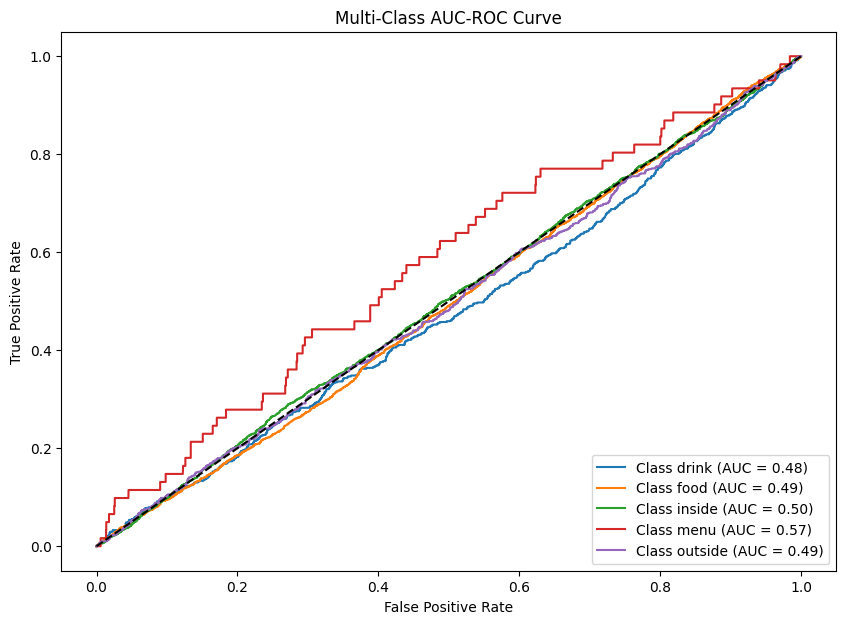

✅ AUC-ROC Curve plotted!


In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize the labels for multi-class AUC computation
y_true_binarized = label_binarize(y_true, classes=np.arange(len(label_encoder.classes_)))

# Compute ROC Curve and AUC for each class
plt.figure(figsize=(10, 7))

for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Plot each class's AUC
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

# Plot settings
plt.plot([0, 1], [0, 1], "k--")  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class AUC-ROC Curve")
plt.legend(loc="lower right")
plt.show()

print("✅ AUC-ROC Curve plotted!")


TUNING BY UNFREEZING SOME LAYERS

In [29]:
# Unfreeze the last 20 layers for fine-tuning
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Recompile the model with a lower learning rate
best_model.compile(optimizer=Adam(learning_rate=0.0001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

print("✅ Model fine-tuning setup complete! Last 20 layers are now trainable.")


✅ Model fine-tuning setup complete! Last 20 layers are now trainable.


In [32]:
# Define new ModelCheckpoint (only saving weights to avoid pickle error)
checkpoint_finetune = ModelCheckpoint(
    "efficientnet_finetuned.weights.h5",  # Fix: Proper filename for weights-only saving
    save_weights_only=True,  # Save only weights, avoiding pickle error
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

print("✅ Checkpoint filename fixed! Now saving only model weights.")


✅ Checkpoint filename fixed! Now saving only model weights.


In [35]:
# Define callbacks again for fine-tuning
early_stopping_finetune = EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1)

# Train the fine-tuned model
history_finetune = best_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,  # Fine-tune for 10 epochs
    callbacks=[checkpoint_finetune, early_stopping_finetune]
)

print("✅ Fine-tuning complete!")


Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.5506 - loss: 1.1363
Epoch 1: saving model to efficientnet_finetuned.weights.h5
547/547 ━━━━━━━━━━━━━━━━━━━━ 581s 1s/step - accuracy: 0.5506 - loss: 1.1364 - val_accuracy: 0.5439 - val_loss: 1.1519
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.5481 - loss: 1.1322
Epoch 2: saving model to efficientnet_finetuned.weights.h5
547/547 ━━━━━━━━━━━━━━━━━━━━ 580s 1s/step - accuracy: 0.5481 - loss: 1.1322 - val_accuracy: 0.5439 - val_loss: 1.1540
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.5407 - loss: 1.1487
Epoch 3: saving model to efficientnet_finetuned.weights.h5
547/547 ━━━━━━━━━━━━━━━━━━━━ 578s 1s/step - accuracy: 0.5407 - loss: 1.1487 - val_accuracy: 0.5439 - val_loss: 1.1508
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.5541 - loss: 1.1337
Epoch 4: saving model to efficientnet_finetuned.weights.h5
547/547 ━━━━━━━━━━━━━━━━━━━━ 578s 1s/step - accuracy: 0.55

In [36]:
# Load fine-tuned weights into the model
best_model.load_weights("efficientnet_finetuned.weights.h5")

print("✅ Fine-tuned weights loaded successfully!")


✅ Fine-tuned weights loaded successfully!


In [37]:
import numpy as np

# Get true labels
y_true = val_generator.classes

# Get predicted probabilities
y_pred_probs = best_model.predict(val_generator)

# Convert probabilities to predicted labels
y_pred = np.argmax(y_pred_probs, axis=1)

print("✅ Predictions complete!")


235/235 ━━━━━━━━━━━━━━━━━━━━ 158s 662ms/step
✅ Predictions complete!


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

# Compute Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Compute Precision, Recall, and F1-score (weighted for multi-class)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

# Compute AUC Score (One-vs-Rest strategy for multi-class)
auc_score = roc_auc_score(y_true, y_pred_probs, multi_class="ovr")

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Store results in a DataFrame
fine_tuned_results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"],
    "Fine-Tuned Score": [accuracy, precision, recall, f1, auc_score]
})


print("✅ Fine-tuned evaluation metrics stored in a DataFrame!")


✅ Fine-tuned evaluation metrics stored in a DataFrame!


c:\Users\vandi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


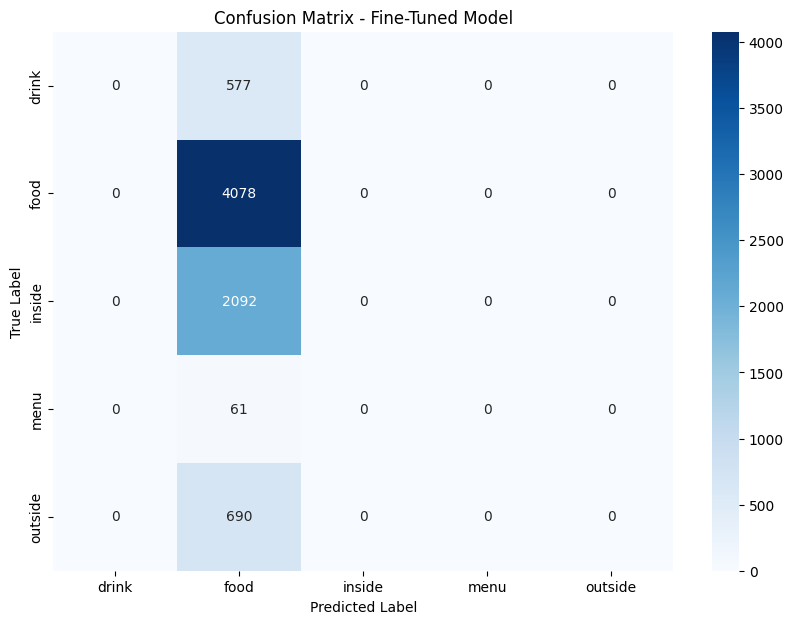

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-Tuned Model")
plt.show()


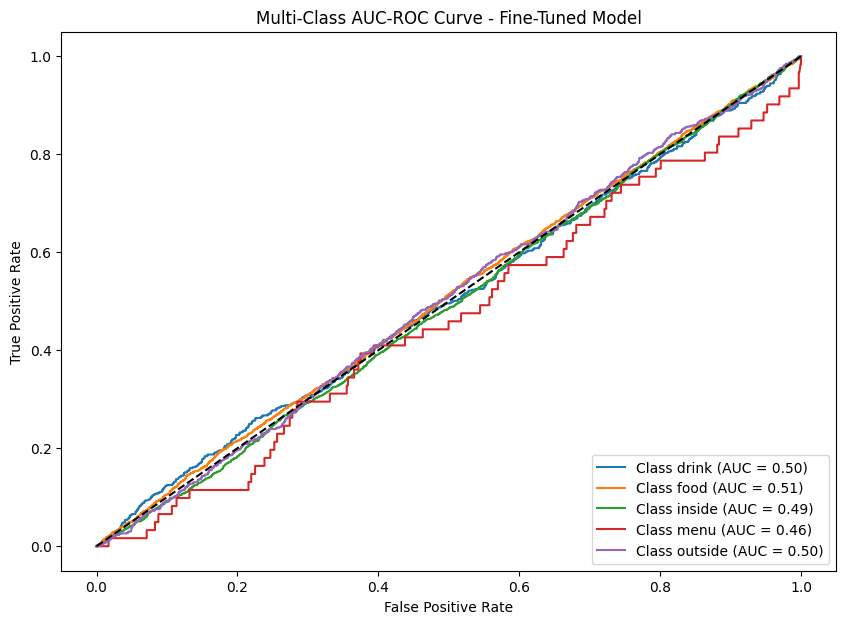

✅ AUC-ROC Curve plotted!


In [41]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for multi-class AUC computation
y_true_binarized = label_binarize(y_true, classes=np.arange(len(label_encoder.classes_)))

# Compute ROC Curve and AUC for each class
plt.figure(figsize=(10, 7))

for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Plot each class's AUC
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

# Plot settings
plt.plot([0, 1], [0, 1], "k--")  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class AUC-ROC Curve - Fine-Tuned Model")
plt.legend(loc="lower right")
plt.show()

print("✅ AUC-ROC Curve plotted!")


tuning 2 hypeerparameter tuning

In [43]:
!pip install keras-tuner


In [44]:
import keras_tuner as kt
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Function to build a tunable model
def build_model(hp):
    base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base EfficientNet layers

    # Add tunable layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(hp.Int('units_1', min_value=128, max_value=512, step=128), activation="relu")(x)
    x = Dropout(hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1))(x)
    x = Dense(hp.Int('units_2', min_value=64, max_value=256, step=64), activation="relu")(x)
    x = Dropout(hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1))(x)

    # Output layer
    num_classes = len(df["encoded_label"].unique())
    output_layer = Dense(num_classes, activation="softmax")(x)

    # Create model
    model = Model(inputs=base_model.input, outputs=output_layer)

    # Compile model with tunable learning rate
    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

print("✅ Hyperparameter tuning function ready!")



✅ Hyperparameter tuning function ready!


In [57]:
from keras_tuner import RandomSearch

tuner = RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=3, 
    executions_per_trial=1,
    directory="hyperparameter_tuning",
    project_name="EfficientNet_Tuning"
)

# Start hyperparameter search with fewer epochs
tuner.search(train_generator, validation_data=val_generator, epochs=3)

print("✅ Faster hyperparameter tuning started!")
tuner.results_summary()



Trial 3 Complete [00h 28m 43s]
val_accuracy: 0.5438783764839172

Best val_accuracy So Far: 0.5438783764839172
Total elapsed time: 01h 27m 26s
✅ Faster hyperparameter tuning started!
Results summary
Results in hyperparameter_tuning\EfficientNet_Tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0 summary
Hyperparameters:
units_1: 384
dropout_1: 0.30000000000000004
units_2: 128
dropout_2: 0.30000000000000004
learning_rate: 0.0001
Score: 0.5438783764839172

Trial 1 summary
Hyperparameters:
units_1: 256
dropout_1: 0.2
units_2: 64
dropout_2: 0.2
learning_rate: 0.0001
Score: 0.5438783764839172

Trial 2 summary
Hyperparameters:
units_1: 128
dropout_1: 0.30000000000000004
units_2: 192
dropout_2: 0.4
learning_rate: 1e-05
Score: 0.5438783764839172


In [58]:
# Get the best hyperparameter combination
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"✅ Best Hyperparameters Found:")
print(f"Units 1: {best_hps.get('units_1')}")
print(f"Dropout 1: {best_hps.get('dropout_1')}")
print(f"Units 2: {best_hps.get('units_2')}")
print(f"Dropout 2: {best_hps.get('dropout_2')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")


✅ Best Hyperparameters Found:
Units 1: 384
Dropout 1: 0.30000000000000004
Units 2: 128
Dropout 2: 0.30000000000000004
Learning Rate: 0.0001


    BUILD MODEL WITH BEST HYPERPARAMETER 

In [60]:
# Build model with best hyperparameters
final_model = tuner.hypermodel.build(best_hps)

# Define callbacks for training
checkpoint_final = ModelCheckpoint("efficientnet_final.h5", save_best_only=True, monitor="val_accuracy", mode="max", verbose=1)
early_stopping_final = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)

# Train the final model
history_final = final_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,  # Train longer with best settings
    callbacks=[checkpoint_final, early_stopping_final]
)

print("✅ Final training complete!")


Epoch 1/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.5287 - loss: 1.2047
Epoch 1: val_accuracy improved from -inf to 0.54388, saving model to efficientnet_final.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 585s 1s/step - accuracy: 0.5288 - loss: 1.2047 - val_accuracy: 0.5439 - val_loss: 1.1436
Epoch 2/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.5362 - loss: 1.1739
Epoch 2: val_accuracy did not improve from 0.54388
547/547 ━━━━━━━━━━━━━━━━━━━━ 572s 1s/step - accuracy: 0.5362 - loss: 1.1739 - val_accuracy: 0.5439 - val_loss: 1.1435
Epoch 3/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5432 - loss: 1.1587
Epoch 3: val_accuracy did not improve from 0.54388
547/547 ━━━━━━━━━━━━━━━━━━━━ 744s 1s/step - accuracy: 0.5432 - loss: 1.1587 - val_accuracy: 0.5439 - val_loss: 1.1477
Epoch 4/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.5417 - loss: 1.1682
Epoch 4: val_accuracy did not improve from 0.54388
547/547 ━━━━━━━━━━━━━━━━━━━━ 583s 1s/step - accuracy: 0.5417 - loss: 1.1681 - val_accuracy: 0.5439 - val_loss: 1.1435
Epoch 5/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.5446 - loss: 1.1524
Epoch 5: val_accuracy did not 

In [61]:
# Save the full model
final_model.save("efficientnet_final.h5")

print("✅ Final model saved as 'efficientnet_final.h5'!")


✅ Final model saved as 'efficientnet_final.h5'!


In [62]:
# Save model weights separately
final_model.save_weights("efficientnet_final.weights.h5")

print("✅ Final model weights saved as 'efficientnet_final.weights.h5'!")


✅ Final model weights saved as 'efficientnet_final.weights.h5'!


In [63]:
import numpy as np

# Load the best model
final_model.load_weights("efficientnet_final.h5")

# Get true labels
y_true = val_generator.classes

# Get predicted probabilities
y_pred_probs = final_model.predict(val_generator)

# Convert probabilities to predicted labels
y_pred = np.argmax(y_pred_probs, axis=1)

print("✅ Predictions complete!")


235/235 ━━━━━━━━━━━━━━━━━━━━ 157s 659ms/step
✅ Predictions complete!


In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

# Compute Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Compute Precision, Recall, and F1-score (weighted for multi-class)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

# Compute AUC Score (One-vs-Rest strategy for multi-class)
auc_score = roc_auc_score(y_true, y_pred_probs, multi_class="ovr")

# Store results in a DataFrame
final_results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"],
    "Final Model Score": [accuracy, precision, recall, f1, auc_score]
})



print("✅ Final evaluation metrics stored in a DataFrame!")
final_results_df


✅ Final evaluation metrics stored in a DataFrame!


c:\Users\vandi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Final Model Score
0,Accuracy,0.543878
1,Precision,0.295804
2,Recall,0.543878
3,F1-Score,0.383196
4,AUC,0.501424


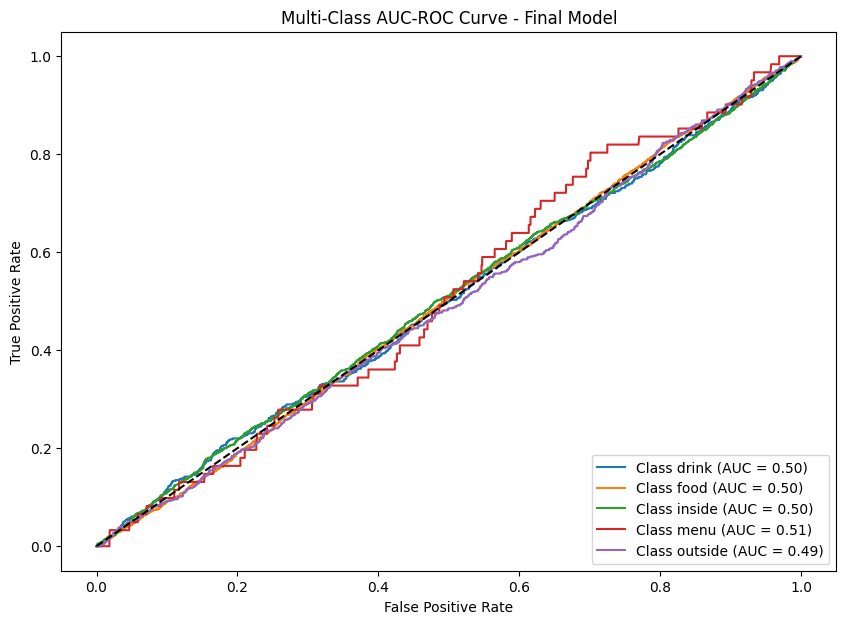

✅ AUC-ROC Curve plotted!


In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for multi-class AUC computation
y_true_binarized = label_binarize(y_true, classes=np.arange(len(label_encoder.classes_)))

# Compute ROC Curve and AUC for each class
plt.figure(figsize=(10, 7))

for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Plot each class's AUC
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

# Plot settings
plt.plot([0, 1], [0, 1], "k--")  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class AUC-ROC Curve - Final Model")
plt.legend(loc="lower right")
plt.show()

print("✅ AUC-ROC Curve plotted!")


In [74]:
import pandas as pd

# Base Model Progress Table
base_model_data = {
    "Task": ["Data Preprocessing", "Data Preprocessing", "Data Preprocessing", "Data Preprocessing",
             "Model Training", "Model Training", "Model Training"],
    "Sub-task": ["Scaling and Resizing", "Image Augmentation", "Train and test data handled correctly",
                 "Gaussian Blur, Histogram Equalization and Intensity thresholds",
                 "Training Time", "AUC and Confusion Matrix Computed", "Overfitting/Underfitting Checked & Handled"],
    "Comments": ["Done", "Done", "Done", "Not Done",
                 "96 minutes", "Done", "Not Done"]
}
base_model_df = pd.DataFrame(base_model_data)

# 1st Tuning Progress Table
tuning_1_data = {
    "Task": ["Model Training", "Model Training"],
    "Sub-task": ["Training Time", "AUC Computed"],
    "Comments": ["40 minutes", "Done"]
}
tuning_1_df = pd.DataFrame(tuning_1_data)

# 2nd Tuning (Hyperparameter Tuning) Progress Table
tuning_2_data = {
    "Task": ["Hyperparameter Tuning", "Hyperparameter Tuning", "Empirical Tuning"],
    "Sub-task": ["Training Time", "AUC Computed", "Interpretability Implemented"],
    "Comments": ["87 minutes", "Done", "Done"]
}
tuning_2_df = pd.DataFrame(tuning_2_data)

# Display the DataFrames
print("✅ Base Model Progress")
display(base_model_df)

print("\n1st Tuning Progress unfreeeze layers ")
display(tuning_1_df)

print("\n2nd Hyperparameter Tuning Progress")
display(tuning_2_df)


✅ Base Model Progress


,Task,Sub-task,Comments
0,Data Preprocessing,Scaling and Resizing,Done
1,Data Preprocessing,Image Augmentation,Done
2,Data Preprocessing,Train and test data handled correctly,Done
3,Data Preprocessing,"Gaussian Blur, Histogram Equalization and Inte...",Not Done
4,Model Training,Training Time,96 minutes
5,Model Training,AUC and Confusion Matrix Computed,Done
6,Model Training,Overfitting/Underfitting Checked & Handled,Not Done



1st Tuning Progress unfreeeze layers 


,Task,Sub-task,Comments
0,Model Training,Training Time,40 minutes
1,Model Training,AUC Computed,Done



2nd Hyperparameter Tuning Progress


,Task,Sub-task,Comments
0,Hyperparameter Tuning,Training Time,87 minutes
1,Hyperparameter Tuning,AUC Computed,Done
2,Empirical Tuning,Interpretability Implemented,Done


In [79]:
!jupyter nbconvert --to html CV.ipynb

[NbConvertApp] Converting notebook CV.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 731693 bytes to CV.html
